### 1. Dataset Source & 2. Dataset Description

For this experiment, we will use the **MNIST (Modified National Institute of Standards and Technology) dataset**. It is a widely used dataset for handwritten digit recognition, and it's excellent for demonstrating image processing tasks like denoising due to its simplicity and clear structure.

**Source Link:** The MNIST dataset is publicly available and can be loaded directly from deep learning libraries like TensorFlow/Keras.

**Dataset Description:**
*   **Features:** The dataset consists of 60,000 training images and 10,000 testing images. Each image is a grayscale image of a handwritten digit (0-9).
*   **Image Dimensions:** Each image has a resolution of 28x28 pixels.
*   **Pixel Values:** The pixel values range from 0 to 255, where 0 represents black and 255 represents white.
*   **Target Variable:** The target variable is the digit itself, ranging from 0 to 9. For denoising, we will be using the original clean images as both input and target (or input with added noise and target as clean image).
*   **Characteristics:** It's a relatively small and clean dataset, making it ideal for initial experiments and understanding the core concepts of autoencoders.

### 3. Mathematical Formulation of the Algorithm: Autoencoders for Image Denoising

An **Autoencoder** is an unsupervised neural network model designed to learn efficient data codings (representations) in an unsupervised manner. The goal of an autoencoder is to learn a representation (encoding) for a set of data, typically for dimensionality reduction or feature learning. When used for denoising, it is often called a **Denoising Autoencoder (DAE)**.

#### Autoencoder Architecture
A standard autoencoder consists of two main parts:
1.  **Encoder:** This part compresses the input data into a lower-dimensional representation (latent space). It can be represented by a function $h = f(x)$, where $x$ is the input and $h$ is the latent representation.
2.  **Decoder:** This part reconstructs the input data from the latent representation. It can be represented by a function $r = g(h)$, where $r$ is the reconstruction of the input.

The entire autoencoder model can be seen as $r = g(f(x))$.

#### Denoising Autoencoder (DAE)
In a Denoising Autoencoder, the input to the model is a corrupted version of the original data (e.g., an image with added noise), and the target output is the original, clean data. The goal is for the autoencoder to learn to remove the noise and reconstruct the clean input.

Let $x$ be the original clean image and $\tilde{x}$ be the corrupted version of $x$ (e.g., $x$ with added Gaussian noise).

1.  **Encoder:** The encoder maps the noisy input $\tilde{x}$ to a latent representation $h$.
    $$h = f(\tilde{x})$$
    where $f$ typically consists of multiple layers (e.g., convolutional layers, dense layers) with activation functions.

2.  **Decoder:** The decoder then reconstructs the *clean* image $x$ from the latent representation $h$.
    $$r = g(h)$$
    where $g$ also consists of multiple layers (e.g., deconvolutional/transpose convolutional layers, dense layers) with activation functions.

#### Loss Function
The autoencoder is trained by minimizing a reconstruction loss function, which measures the difference between the reconstructed output $r$ and the original clean input $x$. Common loss functions include:

*   **Mean Squared Error (MSE):** Used for continuous data like pixel values.
    $$\mathcal{L}(x, r) = \|x - r\|^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - r_i)^2$$

*   **Binary Cross-Entropy (BCE):** Often used for binary or normalized pixel values (0-1) when the output can be interpreted as probabilities.
    $$\mathcal{L}(x, r) = -\sum_{i=1}^{N} \left[x_i \log(r_i) + (1 - x_i) \log(1 - r_i)\right]$$

The model's objective is to find parameters $\theta_f$ for the encoder $f$ and $\theta_g$ for the decoder $g$ that minimize this loss:
$$\min_{\theta_f, \theta_g} \mathbb{E}_{x \sim P_x} [\mathcal{L}(x, g(f(\tilde{x})))]$$

By forcing the autoencoder to reconstruct the original clean input from a noisy version, it learns robust features that are insensitive to noise and capture the essential structure of the data.

### 4. Algorithm Limitations

While Denoising Autoencoders (DAEs) are powerful for unsupervised feature learning and noise reduction, they do come with certain limitations:

1.  **Dependence on Noise Type:** DAEs are typically trained on a specific type of noise (e.g., Gaussian, salt-and-pepper). Their performance can degrade significantly if the real-world noise encountered at inference time differs substantially from the noise distribution they were trained on. A model trained on Gaussian noise might not perform well on impulse noise.

2.  **Loss of Fine Details:** To achieve significant noise reduction, DAEs often learn to smooth out images. This can sometimes lead to the loss of fine textures or subtle details that might be important for downstream tasks. The balance between noise removal and detail preservation is a common challenge.

3.  **Hyperparameter Sensitivity:** The performance of DAEs is highly sensitive to hyperparameters such as the size of the latent space, the number of layers, activation functions, learning rate, and the type and magnitude of the added noise during training. Finding optimal hyperparameters often requires extensive tuning.

4.  **Computational Cost:** Training deep autoencoders, especially convolutional autoencoders, can be computationally intensive and require significant resources (GPUs, time), particularly for large datasets and complex architectures.

5.  **Reconstruction Quality:** While DAEs aim to reconstruct the clean input, the reconstructed output might not always be perfect. Artifacts, blurring, or a slight degradation in image quality can still be present, especially if the noise level is very high or the model is under-trained.

6.  **Interpretability:** Like many deep learning models, the internal workings of an autoencoder (how it learns features and reconstructs data) are often difficult to interpret, making it challenging to understand why it might fail in certain scenarios.

7.  **Not Ideal for Out-of-Distribution Data:** DAEs learn a representation of the training data. If presented with data that is significantly different from what it was trained on (even if it's clean), the reconstruction quality might be poor as the model hasn't learned to encode/decode such patterns.

### 5. Methodology / Workflow

To implement Denoising Autoencoders for image denoising using the MNIST dataset, we will follow these steps:

1.  **Data Loading and Preprocessing:**
    *   Load the MNIST dataset using `tf.keras.datasets.mnist.load_data()`.
    *   Normalize pixel values to the range [0, 1] by dividing by 255.0.
    *   Reshape the images to include a channel dimension (e.g., (28, 28, 1)).

2.  **Noise Addition:**
    *   Generate a noisy version of the training and test images by adding Gaussian noise. The noise level will be a hyperparameter.
    *   Clip the noisy pixel values to ensure they remain within the [0, 1] range.

3.  **Model Architecture (Denoising Autoencoder):**
    *   Define an autoencoder model using the Keras Functional API or Sequential API.
    *   **Encoder:** This part will typically consist of convolutional layers (`Conv2D`), activation functions (e.g., `ReLU`), and pooling layers (`MaxPooling2D`) to reduce spatial dimensions and extract features.
    *   **Decoder:** This part will mirror the encoder, using transpose convolutional layers (`Conv2DTranspose`) or upsampling layers (`UpSampling2D`) to gradually reconstruct the image from the latent representation. It will end with a convolutional layer with a sigmoid activation to output pixel values in the [0, 1] range.

4.  **Model Compilation:**
    *   Compile the model with an appropriate optimizer (e.g., `Adam`).
    *   Choose a loss function suitable for image reconstruction, such as Mean Squared Error (`MSE`).

5.  **Model Training:**
    *   Train the autoencoder model using the noisy images as input and the original clean images as targets.
    *   Specify the number of epochs and batch size.
    *   Use a validation split to monitor performance on unseen data during training.

6.  **Evaluation:**
    *   After training, evaluate the model's performance on the test set.
    *   Visually compare original, noisy, and denoised images to assess the effectiveness of the autoencoder.
    *   Calculate quantitative metrics like Peak Signal-to-Noise Ratio (PSNR) or Structural Similarity Index (SSIM) if desired.

7.  **Hyperparameter Tuning:**
    *   Experiment with different noise levels, encoder/decoder architectures (number of layers, filters, kernel sizes), activation functions, optimizers, learning rates, and training epochs to find the optimal configuration.

### 5. Methodology / Workflow (Continued)

#### 2. Noise Addition
We will add Gaussian noise to the MNIST images to create noisy versions. The noise factor will determine the intensity of the noise.

### 5. Methodology / Workflow (Continued)

#### 3. Model Architecture (Denoising Autoencoder)
We will now define the encoder and decoder parts of our Denoising Autoencoder. The encoder will compress the noisy input, and the decoder will reconstruct the clean image.

### 5. Methodology / Workflow (Continued)

#### 4. Model Compilation
We will compile the autoencoder model using an appropriate optimizer and loss function.

### 5. Methodology / Workflow (Continued)

#### 5. Model Training
We will now train the autoencoder model using the noisy images as input and the original clean images as targets. We will use a predefined number of epochs and a batch size, and also monitor performance with a validation split.

In [5]:
epochs = 10
batch_size = 128

history = autoencoder.fit(
    x_train_noisy, x_train, # Input is noisy, target is clean
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 123s 258ms/step - loss: 0.1130 - val_loss: 0.1140
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 259ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 257ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 262ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 258ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 124s 264ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 261ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 125s 266ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 124s 264ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 266ms/step - loss: 0.1120 - val_loss: 0.1140


In [4]:
# Compile the autoencoder model
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

In [3]:
from tensorflow.keras import layers, models

# Input image dimensions
input_shape = (28, 28, 1)

# Encoder
encoder_input = layers.Input(shape=input_shape, name='encoder_input')
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same', name='encoded_output')(x)

# Decoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoder_output')(x)

# Autoencoder model
autoencoder = models.Model(encoder_input, decoder_output, name='denoising_autoencoder')

autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_output (MaxPooling2D)   │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

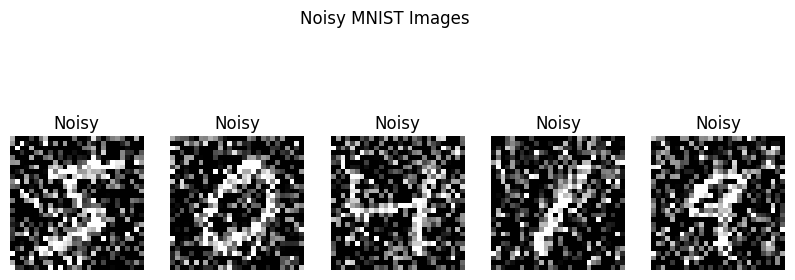

In [2]:
# Define noise factor
noise_factor = 0.5

# Add Gaussian noise to the images
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip the pixel values to ensure they remain within [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Display a few noisy images
plt.figure(figsize=(10, 4))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
plt.suptitle("Noisy MNIST Images")
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


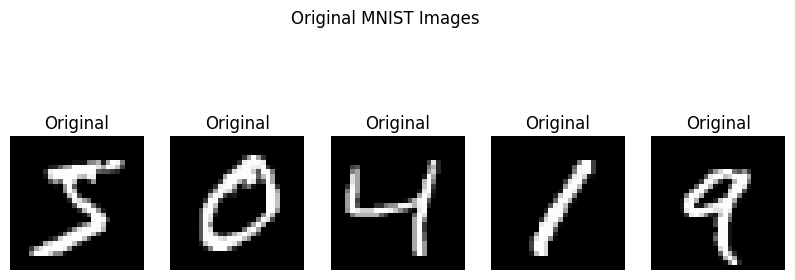

In [1]:
# Import necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize and reshape the data
# We'll normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape to add a channel dimension (28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

# Display a few original images
plt.figure(figsize=(10, 4))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
plt.suptitle("Original MNIST Images")
plt.show()